# Preprocessing

In questo notebook verranno eseguite tutte le attività di preprocessing del dataset.
Ogni split/preprocessamento dei dati sarà salvato nella cartella apposita "data/processed".

## Download dataset

Scarichiamo il dataset con il codice fornito direttamente da *kaggle*

In [2]:
import kagglehub

# Download diretta da kaggle
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

c:\Users\Matteo\anaconda3\envs\DL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Matteo\.cache\kagglehub\datasets\msambare\fer2013\versions\1


## Visualizzazione immagini

Visualizziamo 12 immagini assieme alle rispettive etichette per farci un'idea delle immagini che compongono il dataset 

In [ ]:

import random
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


dataset_path = Path(path)

valid_extensions = [".jpg"]
all_images = [
    p for p in dataset_path.rglob("*") if p.suffix.lower() in valid_extensions
]

if not all_images:
    print(
        f"Nessuna immagine presente nel percorso: {dataset_path}"
    )
else:
    num_samples = 12
    samples = random.sample(all_images, min(num_samples, len(all_images)))

    num_rows = 2
    num_cols = 6

    plt.figure(figsize=(18, 7))

    for idx, img_path in enumerate(samples):
        emotion_class = img_path.parent.name
        title = f"Classe: {emotion_class}"

        img = Image.open(img_path)

        plt.subplot(num_rows, num_cols, idx + 1)

        plt.imshow(img, cmap="gray" if img.mode == "L" else None)
        plt.title(title, fontsize=11, fontweight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Preprocessing

Utilizziamo una funzione per applicare delle leggere modifice alle immagini per generare più campioni.
Le tecniche di preprocessing che andremo ad applicare sono:
- Flip orizzontale
- Traslazione
- Rotazione
- Zoom
- Normalizzazione 

### Funzione per il preprocessing delle immagini

Text(0.5, 1.0, 'distribution of pixels')

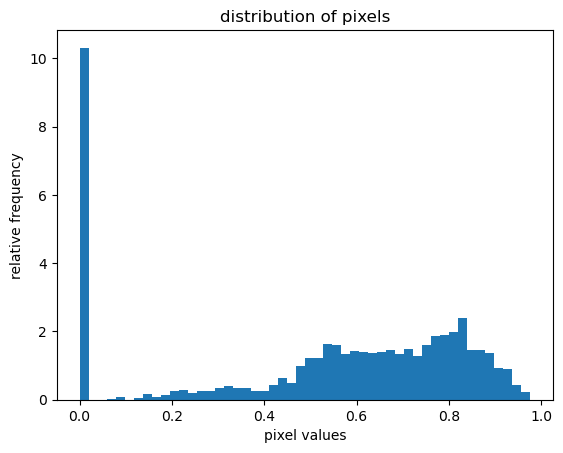

In [ ]:
import torchvision.transforms as transforms

# Pipeline per preprocessing
def get_preprocessing_pipeline():
    preprocessing = transforms.Compose(
        [
            # 1. Flip Orizzontale casuale
            transforms.RandomHorizontalFlip(p=0.5),
            
            # 2. Rotazione casuale
            transforms.RandomRotation(degrees=15, fill=0),
            
            # 3. Traslazione e Zoom leggero
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), fill=0),
            
            # Conversione in tensore
            transforms.ToTensor(),
            
            # 5. Normalizzazione
            #transforms.Normalize(mean=[0.5], std=[0.5])
        ]
    )
    return preprocessing

In [ ]:
# Utilizziamo una funzione per rilevare il percorso del pc
# Così si evitano problemi con l'utilizzo di altri pc 

import os

def get_wd():
    notebook_dir = Path(os.getcwd())

    project_root = notebook_dir.parent

    final_path = project_root / "data"

    return Path(final_path)

#print(get_wd())

### Preprocessing

In [45]:
import random
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

data_root = get_wd()

dataset_originale_path = data_root / "original" / "train"
print(dataset_originale_path)
dataset_processed_path = data_root / "processed"


pipeline = get_preprocessing_pipeline()

# Conversione da tensore a immagine normale 
def tensor_to_saved_image(tensor):
    tensor = tensor * 0.5 + 0.5
    tensor = tensor.clamp(0, 1) 
    reverse_transform = transforms.ToPILImage()
    return reverse_transform(tensor)


# Controllo dell'estensione dei file (le immagini del dataset sono tutte in .jpg)
valid_extensions = [".jpg"]
all_images = [p for p in dataset_originale_path.rglob("*") if p.suffix.lower() in valid_extensions]


# Prendiamo il 40% delle immagini di training
percentuale_da_prendere = 0.40
num_immagini_da_preprocessare = int(len(all_images) * percentuale_da_prendere)
immagini_selezionate = random.sample(all_images, num_immagini_da_preprocessare)

print(f"Inizio elaborazione di {num_immagini_da_preprocessare} immagini...")

for img_path in immagini_selezionate:
    
    # Prendiamo il nome della cartella per mantenere le label per le immagini preprocessate
    relativo_path = img_path.relative_to(dataset_originale_path)
    
    # Diamo il nuovo percorso (processed) in cui andranno salvate le immagini
    nuovo_percorso_file = dataset_processed_path / relativo_path
    
    # Nel caso in cui manchino le cartelle le creiamo
    # Una volta create questa sezione controllerà solo se esistono
    nuovo_percorso_file.parent.mkdir(parents=True, exist_ok=True)
    
    # Modifica del nome dei file per evitare problemi futuri
    nuovo_percorso_file = nuovo_percorso_file.with_name(f"{img_path.stem}_processed{img_path.suffix}")

    try:
        # Si apre l'immagine
        img_originale = Image.open(img_path)
        
        # Si applicano le modifiche con PyTorch
        img_tensor = pipeline(img_originale)
        
        # Conversione da tensore per evitare problemi di lettura (dato che non si possono visualizzare le immagini se sono tensori)
        img_da_salvare = tensor_to_saved_image(img_tensor)
        
        # Vengono salvati nella cartella 'processed' dentro la sottocartella corretta (la label)
        img_da_salvare.save(nuovo_percorso_file)
        
    # In caso di problemi
    except Exception as e:
        print(f"Errore con il file {img_path.name}: {e}")

print(f"Dati preprocessati correttamente")

c:\Users\Matteo\Documents\GitHub\ProgettoDL_FaceFERward\data\original\train
Inizio elaborazione di 11483 immagini...
Dati preprocessati correttamente


### Split del dataset

##### Avendo già la suddivisione del dataset in train e test:

[COME CI POSSIAMO MUOVERE?
SECONDO ME SI POTREBBERO UNIRE TUTTI I DATI (TRAIN E TEST) PER POI FARE UNO SPLIT NOSTRO
COSI' EVITIAMO PROBLEMI E NON CI PUO' DIRE CHE ABBIAMO UTILIZZATO SEMPRE GLI STESSI DATI PER IL TEST
]

In [ ]:
import os
import shutil
import random
from google.colab import drive


# Define paths
original_dataset_base = '/content/FER2013' # Rimane invariato se l'originale è su Colab
original_train_path = os.path.join(original_dataset_base, 'train')

# MODIFICA QUI: Salviamo lo split all'interno del tuo My Drive personale
split_dataset_base = '/content/drive/MyDrive/FER2013_split'

new_train_path = os.path.join(split_dataset_base, 'train')
new_validation_path = os.path.join(split_dataset_base, 'validation')

split_ratio = 0.8 # 80% for training, 20% for validation

print(f"Splitting data from: {original_train_path}")
print(f"Creating new training set at: {new_train_path}")
print(f"Creating new validation set at: {new_validation_path}")

# Clean up any previous split directories
if os.path.exists(split_dataset_base):
    print(f"Removing existing directory: {split_dataset_base}")
    shutil.rmtree(split_dataset_base)

# Create new base directories for the split dataset
os.makedirs(new_train_path, exist_ok=True)
os.makedirs(new_validation_path, exist_ok=True)

# Get emotion classes (subdirectories, e.g., '0', '1', ..., '6')
emotion_classes = [d for d in os.listdir(original_train_path) if os.path.isdir(os.path.join(original_train_path, d))]
emotion_classes.sort() # Ensure consistent order

if not emotion_classes:
    raise ValueError(f"No emotion class directories found in {original_train_path}. Please check the dataset structure.")

for emotion_class in emotion_classes:
    class_original_path = os.path.join(original_train_path, emotion_class)
    class_new_train_path = os.path.join(new_train_path, emotion_class)
    class_new_validation_path = os.path.join(new_validation_path, emotion_class)

    # Create class-specific directories in the new split structure
    os.makedirs(class_new_train_path, exist_ok=True)
    os.makedirs(class_new_validation_path, exist_ok=True)

    images = [f for f in os.listdir(class_original_path) if os.path.isfile(os.path.join(class_original_path, f))]
    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    validation_images = images[split_index:]

    print(f"   Class '{emotion_class}': {len(train_images)} for training, {len(validation_images)} for validation.")

    # Copy images to new train directory
    for img_name in train_images:
        shutil.copy(os.path.join(class_original_path, img_name), class_new_train_path)

    # Copy images to new validation directory
    for img_name in validation_images:
        shutil.copy(os.path.join(class_original_path, img_name), class_new_validation_path)

print("\nDataset split complete!")
print(f"Training data available at: {new_train_path}")
print(f"Validation data available at: {new_validation_path}")